In [2]:
import pandas as pd
import requests
import os
from IPython.display import display, Markdown
from tqdm.auto import tqdm # makes pretty progress bars
tqdm.pandas()
from dotenv import load_dotenv
load_dotenv()

True

In [3]:
df = pd.read_json('data.flavio.json')

In [4]:
df.columns  #são as mesmas que o do Lula > pq foi o mesmo programa de raspagem. > foi limpar igual.

Index(['id', 'type', 'shortCode', 'caption', 'hashtags', 'mentions', 'url',
       'commentsCount', 'firstComment', 'latestComments', 'dimensionsHeight',
       'dimensionsWidth', 'displayUrl', 'images', 'videoUrl', 'likesCount',
       'videoViewCount', 'timestamp', 'childPosts', 'ownerFullName',
       'ownerUsername', 'ownerId', 'productType', 'isCommentsDisabled',
       'inputUrl', 'originalHeight', 'originalWidth', 'audioUrl', 'alt',
       'videoDuration', 'musicInfo', 'videoPlayCount', 'isPinned',
       'taggedUsers', 'coauthorProducers', 'locationName', 'locationId'],
      dtype='str')

In [4]:
#clean the data
#how to drop columns we don't need
#drop(columns=['x', 'y'], inplace=True)

In [5]:
df_clean_flavio = df.drop(columns=['dimensionsHeight', 'videoDuration', 'displayUrl', 'mentions', 'locationName', 'videoViewCount','isPinned', 'images', 'taggedUsers', 'firstComment', 'latestComments', 'videoPlayCount','inputUrl', 'coauthorProducers','productType','locationId','dimensionsWidth', 'musicInfo', 'originalWidth', 'shortCode', 'originalHeight', 'videoUrl','shortCode', 'hashtags', 'childPosts', 'ownerUsername', 'ownerId', 'audioUrl', 'alt', 'ownerFullName'])
df_clean_flavio.columns

Index(['id', 'type', 'caption', 'url', 'commentsCount', 'likesCount',
       'timestamp', 'isCommentsDisabled'],
      dtype='str')

In [6]:
#653 publicações. > e nenhum id é nulo, então > são 653 publicações.
#tem alguma que é nula? > nenhum das que eu vou analisar.

In [ ]:
#mas todas elas tem legendas ?

In [7]:
#Timestamp > é a coluna com data e horário > quero só o mês.> mas antes quero confirmar que só tem o ano de 2026.

In [6]:
df_clean_flavio['date'] = df_clean_flavio['timestamp'].dt.date
df_clean_flavio['date']

0      2026-07-08
1      2022-10-31
2      2026-07-05
3      2026-07-08
4      2026-07-08
          ...    
648    2026-04-26
649    2026-02-04
650    2026-03-12
651    2026-03-23
652    2026-01-03
Name: date, Length: 653, dtype: object

In [7]:
df_clean_flavio["date"] = pd.to_datetime(df_clean_flavio["date"])
df_clean_flavio["date"]

0     2026-07-08
1     2022-10-31
2     2026-07-05
3     2026-07-08
4     2026-07-08
         ...    
648   2026-04-26
649   2026-02-04
650   2026-03-12
651   2026-03-23
652   2026-01-03
Name: date, Length: 653, dtype: datetime64[s]

In [8]:
df_clean_flavio["date"].dt.year.unique()

array([2026, 2022, 2025], dtype=int32)

In [11]:
#Apesar do comando, Apify tinha pegado publicações desde 2022.

In [12]:
#selecionar só os de 2026.# e conferi. agora sim. 

In [9]:
df_flavio_2026 = df_clean_flavio[df_clean_flavio["date"].dt.year == 2026].reset_index(drop=True)
df_flavio_2026["date"].dt.year.unique()

array([2026], dtype=int32)

In [14]:
#medir de novo 
#número de  > 651 > nenhum id zero > então são 651 mesmo. 

In [10]:
df_flavio_2026.shape

(651, 9)

In [11]:
df_flavio_2026.isnull().sum()

id                    0
type                  0
caption               0
url                   0
commentsCount         0
likesCount            0
timestamp             0
isCommentsDisabled    0
date                  0
dtype: int64

In [17]:
df_flavio_2026['date'].isna().sum()

np.int64(0)

In [15]:
df_flavio_2026['caption'].isna().sum()

np.int64(0)

In [18]:
#criar uma coluna só com o mês, para ver quantas publicações por mês, em 2026.

In [16]:
df_flavio_2026['month'] = df_flavio_2026['date'].dt.month
df_flavio_2026['month']

0      7
1      7
2      7
3      7
4      6
      ..
646    4
647    2
648    3
649    3
650    1
Name: month, Length: 651, dtype: int32

In [20]:
posts_month = df_flavio_2026['month'].value_counts(ascending=True)
posts_month

month
7     25
1     92
6     93
5    101
2    104
4    105
3    131
Name: count, dtype: int64

In [21]:
posts_month.mean()

np.float64(93.0)

In [22]:
# Flavio publicou cerca de 93 posts por mês entre 1 de janeiro e 5 de julho de 2026.
#o mes que ele mais publicou foi março, com 131 publicações.

In [24]:
#quantas publicações com os comentários desabilitados? > nenhuma.

In [25]:
df_flavio_2026['isCommentsDisabled'].value_counts()

isCommentsDisabled
False    651
Name: count, dtype: int64

In [26]:
#6.695.420 > mais de 6 milhões de comentários nas publicações. 
#top 5 publicações mais comentadas abaixo. 

In [27]:
total_com = df_flavio_2026['commentsCount'].sum()
total_com

np.int64(6695420)

In [28]:
#media de com por post

In [29]:
med_com_post_flavio = 6695420/653
med_com_post_flavio 

10253.32312404288

In [18]:
top5_com_posts = df_flavio_2026.sort_values(by='commentsCount', ascending=False).head(5)
top5_com_posts

,id,type,caption,url,commentsCount,likesCount,timestamp,isCommentsDisabled,date,month
519,3852145407967187473,Video,A oração é o escudo do cristão. Vamos jejuar e...,https://www.instagram.com/p/DV1kdbJCVIR/,123591,1210515,2026-03-13 19:55:02+00:00,False,2026-03-13,3
275,3857645579262171031,Video,Sempre bate uma saudade enorme do tempo em que...,https://www.instagram.com/p/DWJHDc1RxeX/,122426,1325311,2026-03-21 10:00:00+00:00,False,2026-03-21,3
449,3833933806176941715,Video,"LULA ZOMBA DO POVO! \n\nO Carnaval é cultura, ...",https://www.instagram.com/p/DU03nvRibaT/,120416,2185497,2026-02-16 16:54:05+00:00,False,2026-02-16,2
194,3896388460552171137,Video,CPI DO BANCO MASTER JÁ! Chegou a hora de separ...,https://www.instagram.com/p/DYSwKkyJK6B/,99107,786356,2026-05-13 21:00:05+00:00,False,2026-05-13,5
401,3812184307435930232,Video,Que esta mensagem toque o seu coração. Assista...,https://www.instagram.com/p/DTnmW4HCYJ4/,97799,1374274,2026-01-17 16:38:12+00:00,False,2026-01-17,1


In [19]:
top5_com_posts['caption'].value_counts()

caption
A oração é o escudo do cristão. Vamos jejuar e orar por Bolsonaro, pela sua recuperação e para que possa ser conduzido a uma prisão humanitária, como é seu direito. Obrigado pela força e pelas orações de todos vocês!\n\nCom @jairmessiasbolsonaro                                                                                                                                                                                                                                                                                                                                                                     1
Sempre bate uma saudade enorme do tempo em que a gente estava junto no dia a dia, conversando, rindo e falando de tudo um pouco. Hoje, essas conversas estão mais limitadas, mas eu tenho fé de que esse tempo difícil vai passar.\n\nQue Deus continue te abençoando, te dando força, saúde e sabedoria, pai. Pode ter certeza de uma coisa: eu estarei sempre ao seu lado, com amor, orgulho e a c

In [32]:
df_flavio_2026['type'].value_counts()

type
Video      577
Image       39
Sidecar     35
Name: count, dtype: int64

In [33]:
#577 > publicações de vídeos, 39 imagens e 35 carroseis.

In [34]:
###CLASSIFICAÇÃO: DO QUE OS POSTS MAIS FALAM?

In [35]:
#seleciona só as publicações que tem legenda.

In [22]:
df_flavio_2026['caption']

0      O sistema não para a perseguição contra @jairm...
1      Palpites:\nFlávio: Brasil 2 x 1 Noruega\nEduar...
2      Dica: não dê zoom!\nDescobriu? Responde nos co...
3      Um outro Brasil é possível. Estamos no caminho...
4      Quem tem fé não perde a esperança em dias melh...
                             ...                        
646    Vamos pra cima! Ainda temos muito trabalho pel...
647    A rejeição de Lula não para de crescer porque ...
648    O mais novo amigo do Flávio: o Caramelo Chilen...
649    Entre um clique e outro, a certeza de que esta...
650    O Brasil não pode repetir o roteiro da Venezue...
Name: caption, Length: 651, dtype: str

In [27]:
df_flavio_2026.columns

Index(['id', 'type', 'caption', 'url', 'commentsCount', 'likesCount',
       'timestamp', 'isCommentsDisabled', 'date', 'month'],
      dtype='str')

In [ ]:
df_flavio_2026[df_flavio_2026['caption'].str.strip() == '']

In [29]:
df_flavio_2026 = df_flavio_2026[df_flavio_2026['caption'].str.strip() != ''].reset_index(drop=True)
df_flavio_2026.shape

(635, 10)

In [31]:
df_flavio_2026['month']

0      7
1      7
2      7
3      7
4      6
      ..
630    4
631    2
632    3
633    3
634    1
Name: month, Length: 635, dtype: int32

In [32]:
posts_capt_month = df_flavio_2026['month'].value_counts(ascending=True)
posts_capt_month

month
7     25
1     87
6     92
5    100
2    102
4    103
3    126
Name: count, dtype: int64

In [33]:
posts_capt_month.to_csv('posts_capt_month.csv')

In [34]:
87+102+126+103+100+92+25

635

In [37]:
# são 635 publicações com legenda.

In [38]:
#criar uma amostra de 20% do df 
#crio uma coluna vazia com nome 'groundtruth' > pode ser outro.
#e salvo como excel
#verifico e salvo como handcoded.csv.flavio

In [39]:
data_sample_flavio = df_flavio_2026.set_index("url").sample(frac=0.2, random_state=42)
data_sample_flavio.shape

(127, 9)

In [40]:
data_sample_flavio["groundtruth"] = ""
data_sample_flavio.to_csv("flavio_posts_for_hand_classification.csv")

In [41]:
#importar a IA
### setting up our connection to an API client for an AI provider

In [42]:
USE_OPENROUTER=True

from anthropic import Anthropic

if USE_OPENROUTER:
  from openrouter import OpenRouter
else:
  from openai import OpenAI
  from mistralai.client import Mistral

if USE_OPENROUTER:
  openrouter_client = OpenRouter(api_key=os.environ.get("OPENROUTER_API_KEY_LEDE"))
else:
  openai_client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY_LEDE"))
  mistral_client = Mistral(api_key=os.environ.get("MISTRAL_API_KEY_LEDE"))
anthropic_client = Anthropic(api_key=os.environ.get("ANTHROPIC_API_KEY_LEDE"),) # intentionally created outside of the if; we'll use anthropic_client to count tokens (even if we're using openrouter)


In [43]:
#criar o prompt base
#definir categorias

In [44]:
prompt_base = """
Você é um classificador de posts de Instagram do senador Flávio Bolsonaro. Leia o post
abaixo e escolha a categoria que melhor descreve o TEMA PRINCIPAL do post,
dentre estas opções: {categories}

REGRA DE PRIORIDADE: se um post tocar em mais de um tema, escolha a categoria que
recebe MAIS destaque no texto, não apenas a que é mencionada primeiro. 
Além disso, se falar em pt, lula ou esquerda, escolha sempre essa categoria. 
E se citar alguém da família Bolsonaro, sempre escolher a categoria familia_bolsonaro.

Guia de categorias, com exemplos de posts que se encaixam em cada uma:

- familia_bolsonaro: menciona Jair Bolsonaro, ou qualquer membro da família Bolsonaro
  (irmãos, esposa, filhos), com foco pessoal/afetivo ou institucional sobre a família. 
  Se cita prisão humanitária também é sobre isso, porque o pai dele estava nesse tipo de prisão.
  Exemplo: "Sempre bate uma saudade enorme do tempo em que passávamos juntos, dia a
  dia. Feliz aniversário, pai!"

- pt_lula_esquerda: crítica ou menção a petistas, ao PT, ao Lula, ou à esquerda de
  forma geral.
  Exemplo: "LULA ZOMBA DO POVO! O Carnaval é cultura, é tradição, e merece respeito."

- campanha_projetos: fala sobre o futuro, mudanças que pretende fazer, projetos,
  prioridades, ou promessas de campanha. Sobre o Brasil querer mudanças.
  Exemplo: "Nosso projeto para 2027 é claro: segurança, liberdade econômica e respeito
  à família brasileira."

- seguranca: sobre crime, prisão, bandidos, facções (PCC, CV), ou segurança pública em
  geral.
  Exemplo: "Chegou a hora de dar basta à criminalidade que assola nossas cidades."

- religiao: sobre romaria, missa, orações, ou fé de forma geral.

- agronegocio_economia: sobre agronegócio, produção rural, ou temas econômicos como o
  Pix e sistema financeiro.
  Exemplo: "O Pix mudou a vida financeira de milhões de brasileiros."

- outros: futebol, tecnologia, datas comemorativas pessoais sem relação com a família
  Bolsonaro, ou qualquer assunto que não se encaixe claramente nas categorias acima.
  Exemplo: "Boa sorte à Seleção Brasileira na Copa do Mundo!"

Retorne apenas o nome da categoria, exatamente como escrito acima, nada mais.

Aqui está o post: {tweet_text}
"""

In [45]:
#define as categorias

In [46]:
from enum import Enum, IntEnum

class FlavioPostOptions(str, Enum):
    familia_bolsonaro = "familia_bolsonaro"
    pt_lula_esquerda = "pt_lula_esquerda"
    campanha_projetos = "campanha_projetos"
    seguranca = "seguranca"
    religiao = "religiao"
    agronegocio_economia = "agronegocio_economia"
    outros = "outros"

from pydantic import BaseModel

class FlavioPostValidOptions(BaseModel):
    classification: FlavioPostOptions

In [47]:
#cria a coluna com a resposta do prompt.

In [48]:
data_sample_prompt_column = data_sample_flavio.apply(
    lambda row: prompt_base.format(
        tweet_text=row["caption"],
        categories=", ".join(['"{}"'.format(opt.value) for opt in FlavioPostOptions])
    ),
    axis="columns"
)

In [49]:
#mandar para a IA classificar pelo OpenRouter > o return é a resposta do prompt.

In [50]:
def classify(prompt):
    response = openrouter_client.chat.send(
        model="openai/gpt-5.5",
        messages=[{"role": "user", "content": prompt}],
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "flavio_post_classification",
                "strict": True,
                "schema": FlavioPostValidOptions.model_json_schema(),
            },
        },
    )
    return FlavioPostValidOptions.model_validate_json(
        response.choices[0].message.content
    ).classification.value


In [51]:
data_sample_flavio["ai_guess"] = data_sample_prompt_column.progress_apply(classify)

100%|██████████| 127/127 [06:18<00:00,  2.98s/it]


In [52]:
data_sample_flavio["ai_guess"].shape

(127,)

In [53]:
## IMPORTAR CSV MANUAL E COMPARAR COM RESULTADO DA IA

In [54]:
handcoded = pd.read_csv("handcoded.flavio.csv").set_index("url")
handcoded.head()

,id,type,caption,commentsCount,likesCount,timestamp,isCommentsDisabled,date,month,groundtruth
url,,,,,,,,,,
https://www.instagram.com/p/DWKX0vtCflc/,3858000810500290908,Video,Hoje o Rio Grande do Norte pegou fogo! Onde a ...,7228,84216,2026-03-21 21:46:10+00:00,False,2026-03-21,3,campanha_projetos
https://www.instagram.com/p/DW_UpRaCXUh/,3872905001681122593,Video,O presidente @jairmessiasbolsonaro sempre trat...,5622,132151,2026-04-11 11:18:59+00:00,False,2026-04-11,4,familia_bolsonaro
https://www.instagram.com/p/DUj3bVrCKlG/,3829147879449602374,Video,"Meu projeto é o de pacificação do Brasil, é a ...",4438,90996,2026-02-10 02:20:00+00:00,False,2026-02-10,2,campanha_projetos
https://www.instagram.com/p/DXj1NELictO/,3883181298030332750,Video,"No Rio de Janeiro e em todo o Brasil, o trabal...",4869,62955,2026-04-25 15:35:38+00:00,False,2026-04-25,4,pt_lula_esquerda
https://www.instagram.com/p/DXwa2UAh3CX/,3886724559965483159,Video,"Que Deus te abençoe, meu irmão! @flaviobolsonaro",11173,151841,2026-04-30 12:57:12+00:00,False,2026-04-30,4,familia_bolsonaro


In [55]:
#juntar coluna ai guess no meu handcoded

In [56]:
if "groundtruth" not in handcoded.columns:
  print("uh oh, your handcoded.csv doesn't have a column named groundtruth")
  assert "groundtruth" in handcoded.columns
if handcoded.groundtruth.isna().any() or (handcoded.groundtruth == '').any():
  print("uh oh, there are some blanks in your handcoded.csv's groundtruth column. go fix that!")

# if the ai_guess column got lost in the process... we'll grab it again
if "ai_guess" not in handcoded:
  handcoded = handcoded.merge(data_sample_flavio[["ai_guess"]], right_index=True, left_index=True, how="left")

In [57]:
#dá uma checada para ver se as duas colunas (groudtruth e ia guess estão completadas)

In [58]:
handcoded.to_csv('oquerolou.csv')

In [59]:
handcoded.head()

,id,type,caption,commentsCount,likesCount,timestamp,isCommentsDisabled,date,month,groundtruth,ai_guess
url,,,,,,,,,,,
https://www.instagram.com/p/DWKX0vtCflc/,3858000810500290908,Video,Hoje o Rio Grande do Norte pegou fogo! Onde a ...,7228,84216,2026-03-21 21:46:10+00:00,False,2026-03-21,3,campanha_projetos,campanha_projetos
https://www.instagram.com/p/DW_UpRaCXUh/,3872905001681122593,Video,O presidente @jairmessiasbolsonaro sempre trat...,5622,132151,2026-04-11 11:18:59+00:00,False,2026-04-11,4,familia_bolsonaro,familia_bolsonaro
https://www.instagram.com/p/DUj3bVrCKlG/,3829147879449602374,Video,"Meu projeto é o de pacificação do Brasil, é a ...",4438,90996,2026-02-10 02:20:00+00:00,False,2026-02-10,2,campanha_projetos,campanha_projetos
https://www.instagram.com/p/DXj1NELictO/,3883181298030332750,Video,"No Rio de Janeiro e em todo o Brasil, o trabal...",4869,62955,2026-04-25 15:35:38+00:00,False,2026-04-25,4,pt_lula_esquerda,pt_lula_esquerda
https://www.instagram.com/p/DXwa2UAh3CX/,3886724559965483159,Video,"Que Deus te abençoe, meu irmão! @flaviobolsonaro",11173,151841,2026-04-30 12:57:12+00:00,False,2026-04-30,4,familia_bolsonaro,familia_bolsonaro


In [60]:
from sklearn.metrics import accuracy_score
display(Markdown("Accuracy score: {:.1%}. Is that good?".format(
    accuracy_score(handcoded["groundtruth"], handcoded["ai_guess"])
)))

Accuracy score: 74.8%. Is that good?

IPython.core.display.Markdown

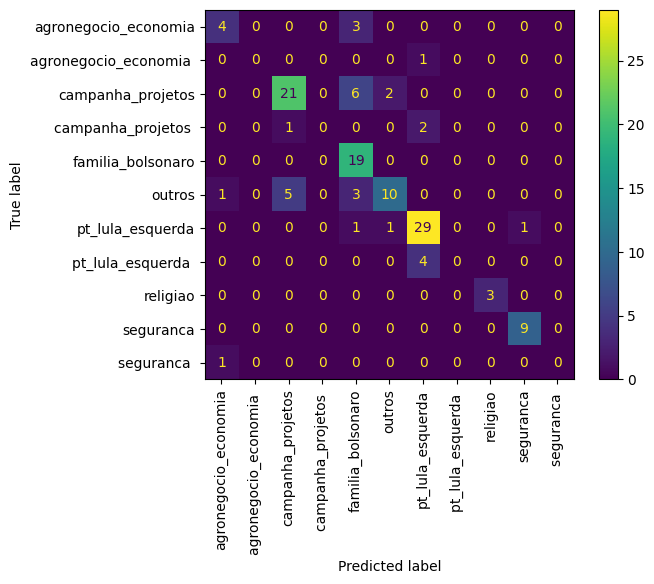

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(handcoded["groundtruth"], handcoded["ai_guess"],  xticks_rotation="vertical");
display(Markdown)

In [63]:
## criando a coluna de prompt para o dataset completo
# usando o prompt_base mais recente (com as categorias guarda-chuva)
data_full_prompt_column = df_flavio_2026.apply(
    lambda row: prompt_base.format(
        tweet_text=row["caption"],
        categories=", ".join(['"{}"'.format(opt.value) for opt in FlavioPostOptions])
    ),
    axis="columns"
)

In [55]:
df_flavio_2026.columns

Index(['id', 'type', 'caption', 'url', 'commentsCount', 'likesCount',
       'timestamp', 'isCommentsDisabled', 'date', 'month'],
      dtype='str')

In [59]:
df_flavio_2026["timestamp"] = pd.to_datetime(df_flavio_2026["timestamp"])

In [60]:
data_dir = "./"

In [61]:
print(data_dir)

./


In [64]:
## classificando o dataset completo
df_flavio_2026["ai_guess"] = data_full_prompt_column.progress_apply(classify)

df_flavio_2026.to_csv(data_dir + "flavio_posts_ai_classified.csv")

100%|██████████| 635/635 [33:01<00:00,  3.12s/it]


In [65]:
df_flavio_2026["ai_guess"]

0      familia_bolsonaro
1      familia_bolsonaro
2                 outros
3      campanha_projetos
4               religiao
             ...        
630    campanha_projetos
631     pt_lula_esquerda
632    familia_bolsonaro
633     pt_lula_esquerda
634     pt_lula_esquerda
Name: ai_guess, Length: 635, dtype: str

In [67]:
assuntos_flavio = df_flavio_2026["ai_guess"].value_counts()
assuntos_flavio

ai_guess
pt_lula_esquerda        189
familia_bolsonaro       142
campanha_projetos       140
outros                   69
seguranca                40
religiao                 28
agronegocio_economia     27
Name: count, dtype: int64

In [72]:
porcentagem = df_flavio_2026["ai_guess"].value_counts(normalize=True)*100
porcentagem

ai_guess
pt_lula_esquerda        29.763780
familia_bolsonaro       22.362205
campanha_projetos       22.047244
outros                  10.866142
seguranca                6.299213
religiao                 4.409449
agronegocio_economia     4.251969
Name: proportion, dtype: float64

In [74]:
tabela = pd.DataFrame({
    "contagem": assuntos_flavio,
    "porcentagem": porcentagem.round(1)
})

tabela

,contagem,porcentagem
ai_guess,,
pt_lula_esquerda,189,29.8
familia_bolsonaro,142,22.4
campanha_projetos,140,22.0
outros,69,10.9
seguranca,40,6.3
religiao,28,4.4
agronegocio_economia,27,4.3


In [75]:
tabela.to_csv('assuntos_flavio.csv')